# Goal : Build a Long-term memory chatbot

## General Agent Architechture
act - let the model call specific tools
observe - pass the tool output back to the model
reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

## Objective: 
    - remove messages to save token usage, latency and cost
    - filter messages 
    - trim messages

In [1]:
%pip install --quiet -U langchain_core langgraph langchain_google_genai 

Note: you may need to restart the kernel to use updated packages.


In [168]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"
                                         

## Set LangSmith tracing

In [169]:
# set LangSmith tracing environment
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'
                                         

In [170]:
# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [53]:
# create a llm
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?")

AIMessage(content=[{'type': 'text', 'text': 'Today is **Tuesday, May 21, 2024**.', 'extras': {'signature': 'EjQKMgEMOdbHZg73I9UovKiSdfbzZnAMhE6UfXkfq2pJx3+UGiHU9Gt6Mpww2tY8GpEClgnR'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019db65e-8b56-7a21-a09e-56f8c779623e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 16, 'total_tokens': 22, 'input_token_details': {'cache_read': 0}})

# Messages as state


In [12]:
# define messages
from langchain_core.messages import AIMessage, HumanMessage

H_msg = HumanMessage(role= "User" , content="I would like to learn Agentic AI" ,name = 'Diya')

messages = [AIMessage(role= "Model" , content="What can I do for you?" , name = "AI_model")]
messages.append(H_msg)

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI_model

What can I do for you?
================================ Human Message =================================
Name: Diya

I would like to learn Agentic AI


## Using AI

In [14]:
result = llm.invoke(messages)


AttributeError: 'tuple' object has no attribute 'pretty_print'

In [17]:
print(result.content)

That's a fantastic area to dive into! Agentic AI is one of the most exciting and rapidly developing frontiers in artificial intelligence. It moves beyond simple prompt-response systems to AI that can *act*, *plan*, *reason*, and *learn* autonomously to achieve complex goals.

Let's break down what Agentic AI is, why it's important, how it works, and how you can start learning it.

---

## What is Agentic AI?

At its core, Agentic AI refers to AI systems designed to operate as **autonomous agents**. Unlike traditional AI models that might perform a single task (like classifying an image or generating text based on a single prompt), an agentic AI system can:

1.  **Perceive:** Understand its environment (e.g., read a document, observe user input, get data from a tool).
2.  **Reason:** Process information, make decisions, and formulate plans.
3.  **Act:** Execute actions in its environment (e.g., use a tool, write code, send an email, interact with a database).
4.  **Reflect/Learn:** Eval

## Build graph with llm

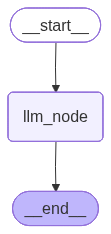

In [33]:
from IPython.display import Image, display
from langgraph.graph import MessagesState , START , StateGraph , END
from typing import Literal

# define nodes and function
# node 1
def llm_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    print("State Messages: " , state['messages'])
    print("response: " , response)
    return {'messages': [response]}

# Build graph
builder = StateGraph(MessagesState)

# add nodes and edges
builder.add_node('llm_node' , llm_node)
builder.add_edge(START , 'llm_node')
builder.add_edge('llm_node', END)

graph = builder.compile()
# view
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
result = graph.invoke({'messages': messages})
                                                   

State Messages:  [AIMessage(content='What can I do for you?', additional_kwargs={}, response_metadata={}, name='AI_model', id='ea50cb67-7110-4059-8cf1-e59f4bc105d4', tool_calls=[], invalid_tool_calls=[], role='Model'), HumanMessage(content='I would like to learn Agentic AI', additional_kwargs={}, response_metadata={}, name='Diya', id='12020f21-1760-499d-9832-9c754745117e', role='User')]
response:  content='That\'s a fantastic area to dive into! **Agentic AI** is one of the most exciting and rapidly evolving fields in artificial intelligence right now, especially with the advent of powerful Large Language Models (LLMs).\n\nLet\'s break down what Agentic AI is, why it\'s important, and how you can start learning about it.\n\n---\n\n### What is Agentic AI?\n\nAt its core, an **Agentic AI system** (or simply an "AI Agent") is an AI designed to act autonomously, make decisions, and pursue goals in an environment, often without constant human intervention.\n\nThink of it less like a static t

In [37]:
for m in result['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI_model

What can I do for you?
================================ Human Message =================================
Name: Diya

I would like to learn Agentic AI
================================== Ai Message ==================================

That's a fantastic area to dive into! **Agentic AI** is one of the most exciting and rapidly evolving fields in artificial intelligence right now, especially with the advent of powerful Large Language Models (LLMs).

Let's break down what Agentic AI is, why it's important, and how you can start learning about it.

---

### What is Agentic AI?

At its core, an **Agentic AI system** (or simply an "AI Agent") is an AI designed to act autonomously, make decisions, and pursue goals in an environment, often without constant human intervention.

Think of it less like a static tool that just responds to a single prompt, and more like a proactive entity that can:

1.  **Pe

# Remove Messages reducer - RemoveMessage

MessagesState is a built in reducer so it removes and updates the state automatically after delted messages are added back to the state


In [158]:
# Create some dummy messages for the state

messages = [AIMessage(content="Hi, I'm a bot" , name ="AI" , id ="1"), 
            HumanMessage(content= "What can you do?" , name="Diya" , id= "2"),
            AIMessage(content="What do you line to learn about?" , name ="AI" , id = "3"),
            HumanMessage(content= "Teach me Langgraph" , name="Diya" , id ="4")
           ]         

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI

Hi, I'm a bot
================================ Human Message =================================
Name: Diya

What can you do?
================================== Ai Message ==================================
Name: AI

What do you line to learn about?
================================ Human Message =================================
Name: Diya

Teach me Langgraph


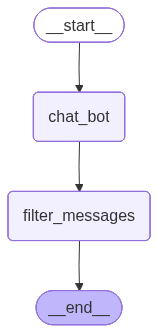

In [109]:
# create graph 
from langchain_core.messages import RemoveMessage

# create a node and add a node function to filter messages
def chat_bot(state:MessagesState):
    return {'messages': [llm.invoke(state['messages'])]}


def filter_messages(state:MessagesState):
    deleted_messages = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    print("Deleted Messages: " , deleted_messages)
    return {'messages': deleted_messages}

#graph
builder = StateGraph(MessagesState)

#add nodes and edges
builder.add_node('chat_bot', chat_bot)
builder.add_node('filter_messages', filter_messages)

builder.set_entry_point('chat_bot')
builder.add_edge('chat_bot', 'filter_messages')
builder.add_edge('filter_messages', END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [110]:
result = graph.invoke({'messages': messages})

Deleted Messages:  [RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='2'), RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='3')]


In [111]:
result['messages'][-1]


AIMessage(content=[{'type': 'text', 'text': 'LangGraph is a library built on top of LangChain that allows you to build **stateful, multi-actor applications** with LLMs.\n\nWhile LangChain is great for linear chains (A -> B -> C), **LangGraph** is designed for **cycles** (loops). This is essential for building "Agents" that need to reason, act, observe, and repeat until a task is finished.\n\nHere is a breakdown of the core concepts to get you started.\n\n---\n\n### 1. The Core Concepts\nTo build a LangGraph application, you need four things:\n\n*   **State:** A shared data structure (usually a TypedDict) that acts as the "memory" for your graph. Every node can read from and write to this state.\n*   **Nodes:** Python functions that perform work (e.g., calling an LLM, searching the web, or processing data).\n*   **Edges:** The logic that determines which node to go to next.\n*   **The Graph:** The container that connects nodes and edges.\n\n---\n\n### 2. A Simple Example\nImagine you wa

In [112]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================
Name: Diya

Teach me Langgraph
================================== Ai Message ==================================

[{'type': 'text', 'text': 'LangGraph is a library built on top of LangChain that allows you to build **stateful, multi-actor applications** with LLMs.\n\nWhile LangChain is great for linear chains (A -> B -> C), **LangGraph** is designed for **cycles** (loops). This is essential for building "Agents" that need to reason, act, observe, and repeat until a task is finished.\n\nHere is a breakdown of the core concepts to get you started.\n\n---\n\n### 1. The Core Concepts\nTo build a LangGraph application, you need four things:\n\n*   **State:** A shared data structure (usually a TypedDict) that acts as the "memory" for your graph. Every node can read from and write to this state.\n*   **Nodes:** Python functions that perform work (e.g., calling an LLM, searching the web, or processing data).\n*   *

# Filtering Messages
Messages cna be filtered before passing into the graph state to avoid token usage or reduce cost and latency

For example, just pass in a filtered list: llm.invoke(messages[-1:]) to the model.


In [159]:
messages

[AIMessage(content="Hi, I'm a bot", additional_kwargs={}, response_metadata={}, name='AI', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What can you do?', additional_kwargs={}, response_metadata={}, name='Diya', id='2'),
 AIMessage(content='What do you line to learn about?', additional_kwargs={}, response_metadata={}, name='AI', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Teach me Langgraph', additional_kwargs={}, response_metadata={}, name='Diya', id='4')]

In [160]:
# append last message from the llm to the messages list

messages.append(result['messages'][-1])
messages.append(HumanMessage(content="Thank you. What companies use Langgraph?" , name ="diya" ))


In [161]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI

Hi, I'm a bot
================================ Human Message =================================
Name: Diya

What can you do?
================================== Ai Message ==================================
Name: AI

What do you line to learn about?
================================ Human Message =================================
Name: Diya

Teach me Langgraph
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Because **LangGraph** is a relatively new framework (released by LangChain in early 2024), it is primarily being adopted by companies that are building **complex, agentic AI workflows**—specifically those that require loops, state management, and human-in-the-loop oversight.\n\nWhile many companies do not publicly disclose their entire internal tech stack, several organizations have publicly discussed, demoed, or integrated LangGraph in

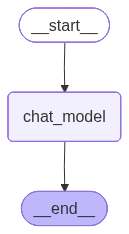

In [116]:
# Build a new graph filtering messages in the nodes

def chat_model(state:MessagesState):
    return {'messages': llm.invoke(state['messages'][-1:])}

builder =StateGraph(MessagesState)

builder.add_node('chat_model',chat_model)

builder.add_edge(START, 'chat_model')
builder.add_edge('chat_model',END)

graph = builder.compile()
graph

In [117]:
# Invoke

result = graph.invoke({'messages': messages})

In [118]:
for m in result['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: AI

Hi, I'm a bot
================================ Human Message =================================
Name: Diya

What can you do?
================================== Ai Message ==================================
Name: AI

What do you line to learn about?
================================ Human Message =================================
Name: Diya

Teach me Langgraph
================================== Ai Message ==================================

[{'type': 'text', 'text': 'LangGraph is a library built on top of LangChain that allows you to build **stateful, multi-actor applications** with LLMs.\n\nWhile LangChain is great for linear chains (A -> B -> C), **LangGraph** is designed for **cycles** (loops). This is essential for building "Agents" that need to reason, act, observe, and repeat until a task is finished.\n\nHere is a breakdown of the core concepts to get you started.\n\n---\n\n### 1. The Core Con

### Note: LLM only uses the last message from the state['messages'] as shown but state carries all the messages

# Trim Messages
When you build a chatbot, the conversation history grows longer and longer.
If you send all messages to the model every time, it becomes:

    - slow
    - expensive
    - and may exceed the model’s token limit
    - So we trim the messages — meaning we keep only the most important recent ones.

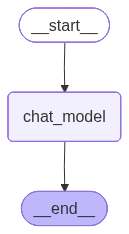

In [163]:
from langchain_core.messages import trim_messages

# create a graph with nodes using tocken limit

def model_with_trimmer(state:MessagesState):
    messages = trim_messages(
               state['messages'],
               max_tokens = 300,
               strategy = 'last',
               token_counter = ChatGoogleGenerativeAI(model="gemini-2.5-flash"),
               allow_partial=False,
               )
    print("Trimmed Messages: " , messages)
    return {'messages': llm.invoke(messages)}

# build graph
builder = StateGraph(MessagesState)

builder.add_node('chat_model', model_with_trimmer)

builder.add_edge(START, 'chat_model')
builder.add_edge('chat_model', END)

graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [162]:
messages.append(result['messages'][-1])
messages.append(HumanMessage(content="List few strtup comapnies I can apply to after learnign langgraph." , name='Diya' , id = '7'))

messages
                

[AIMessage(content="Hi, I'm a bot", additional_kwargs={}, response_metadata={}, name='AI', id='1', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='What can you do?', additional_kwargs={}, response_metadata={}, name='Diya', id='2'),
 AIMessage(content='What do you line to learn about?', additional_kwargs={}, response_metadata={}, name='AI', id='3', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Teach me Langgraph', additional_kwargs={}, response_metadata={}, name='Diya', id='4'),
 AIMessage(content=[{'type': 'text', 'text': 'Because **LangGraph** is a relatively new framework (released by LangChain in early 2024), it is primarily being adopted by companies that are building **complex, agentic AI workflows**—specifically those that require loops, state management, and human-in-the-loop oversight.\n\nWhile many companies do not publicly disclose their entire internal tech stack, several organizations have publicly discussed, demoed, or integrated LangGraph int

In [164]:
# Invoke
result = graph.invoke({'messages': messages})

Trimmed Messages:  [HumanMessage(content='Thank you. What companies use Langgraph?', additional_kwargs={}, response_metadata={}, name='diya', id='a1cdc495-f9cf-45d2-869a-a2fa81c0af89'), HumanMessage(content='List few strtup comapnies I can apply to after learnign langgraph.', additional_kwargs={}, response_metadata={}, name='Diya', id='7')]


In [165]:
for m in result['messages']:
    m.pretty_print()


================================== Ai Message ==================================
Name: AI

Hi, I'm a bot
================================ Human Message =================================
Name: Diya

What can you do?
================================== Ai Message ==================================
Name: AI

What do you line to learn about?
================================ Human Message =================================
Name: Diya

Teach me Langgraph
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Because **LangGraph** is a relatively new framework (released by LangChain in early 2024), it is primarily being adopted by companies that are building **complex, agentic AI workflows**—specifically those that require loops, state management, and human-in-the-loop oversight.\n\nWhile many companies do not publicly disclose their entire internal tech stack, several organizations have publicly discussed, demoed, or integrated LangGraph in

In [167]:
print(result['messages'][-1].text)

LangGraph has quickly become the industry standard for building **agentic workflows** (AI agents that can reason, loop, and handle complex state). Because it is a relatively new framework (built by the LangChain team), companies using it are typically those building advanced, production-grade AI applications rather than simple wrappers.

Here is a breakdown of the types of companies using LangGraph and a list of startups where your skills would be highly valued.

---

### Who uses LangGraph?
1.  **Enterprise AI Platforms:** Companies building internal tools for Fortune 500s (e.g., automated customer support, document analysis).
2.  **AI-Native SaaS:** Companies whose core product is an agent (e.g., coding agents, research agents, sales automation).
3.  **Data & Infrastructure Startups:** Companies building RAG (Retrieval-Augmented Generation) pipelines that require complex, multi-step reasoning.

---

### Startups & Companies to Target
When applying, look for companies that describe th